<a href="https://colab.research.google.com/github/amitdey7/llm-class/blob/main/GPT_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### GPT - 2 Model Architecure

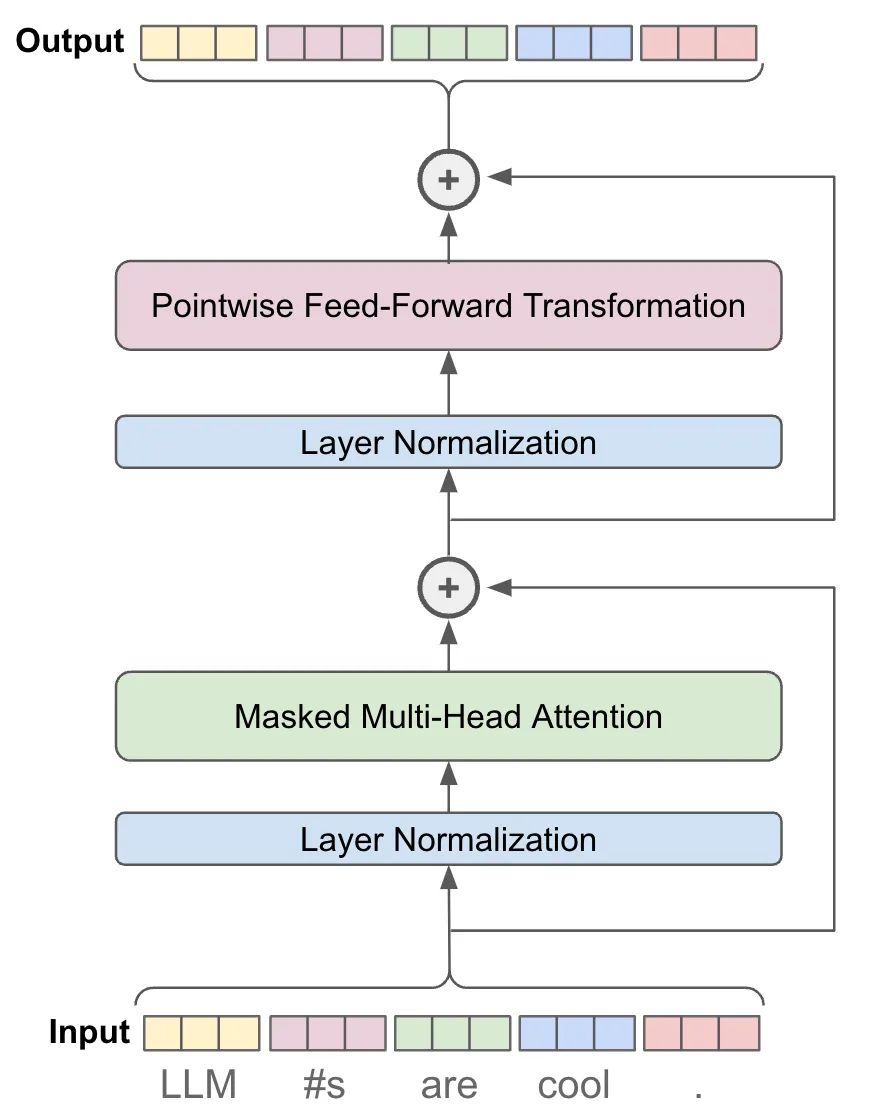

In [ ]:

# Load model
from transformers import AutoTokenizer, AutoModelForCausalLM, TextStreamer

tokenizer = AutoTokenizer.from_pretrained("openai-community/gpt2")
model = AutoModelForCausalLM.from_pretrained("openai-community/gpt2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: openai-community/gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:

streamer = TextStreamer(tokenizer, skip_prompt=True, skip_special_tokens=True)

inputs = tokenizer("The future of large language models is ", return_tensors="pt")

model.generate(
    **inputs,
    max_new_tokens=50,
    streamer=streamer,
)


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


 to be determined by the development of new languages. The future of large language models is  to be determined by the development of new languages.
The future of large language models is  to be determined by the development of new languages.


tensor([[ 464, 2003,  286, 1588, 3303, 4981,  318,  220, 1849, 1462,  307, 5295,
          416,  262, 2478,  286,  649, 8950,   13,  383, 2003,  286, 1588, 3303,
         4981,  318,  220, 1849, 1462,  307, 5295,  416,  262, 2478,  286,  649,
         8950,   13,  198,  464, 2003,  286, 1588, 3303, 4981,  318,  220, 1849,
         1462,  307, 5295,  416,  262, 2478,  286,  649, 8950,   13]])

In [ ]:
print(model)

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)


In [ ]:
GPT_CONFIG_124M = {
"vocab_size": 50257,
"context_length": 1024,
"emb_dim": 768,
"n_heads": 12,
"n_layers": 12,
"drop_rate": 0.1,
"qkv_bias": False
}

In [ ]:
import torch
import torch.nn as nn


class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # Use a placeholder for TransformerBlock
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        # Use a placeholder for LayerNorm
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # A simple placeholder

    def forward(self, x):
        # This block does nothing and just returns its input.
        return x


class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
        # The parameters here are just to mimic the LayerNorm interface.

    def forward(self, x):
        # This layer does nothing and just returns its input.
        return x

In [ ]:
model = DummyGPTModel(GPT_CONFIG_124M)
print(model)

DummyGPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): DummyTransformerBlock()
    (1): DummyTransformerBlock()
    (2): DummyTransformerBlock()
    (3): DummyTransformerBlock()
    (4): DummyTransformerBlock()
    (5): DummyTransformerBlock()
    (6): DummyTransformerBlock()
    (7): DummyTransformerBlock()
    (8): DummyTransformerBlock()
    (9): DummyTransformerBlock()
    (10): DummyTransformerBlock()
    (11): DummyTransformerBlock()
  )
  (final_norm): DummyLayerNorm()
  (out_head): Linear(in_features=768, out_features=50257, bias=False)
)


In [ ]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

batch = []

txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [ ]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)

logits = model(batch)
print("Output shape:", logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


## Layer Normalization

 - Gradient explosion/vanishing issues in deep networks
 - Normalizes (centers) inputs across features for each token to have zero mean and unit variance
 - Stabilizes training and improves convergence
 - in GPT-2, applied before self-attention and feed-forward layers (Pre-LN)
 - also applied before final output layer

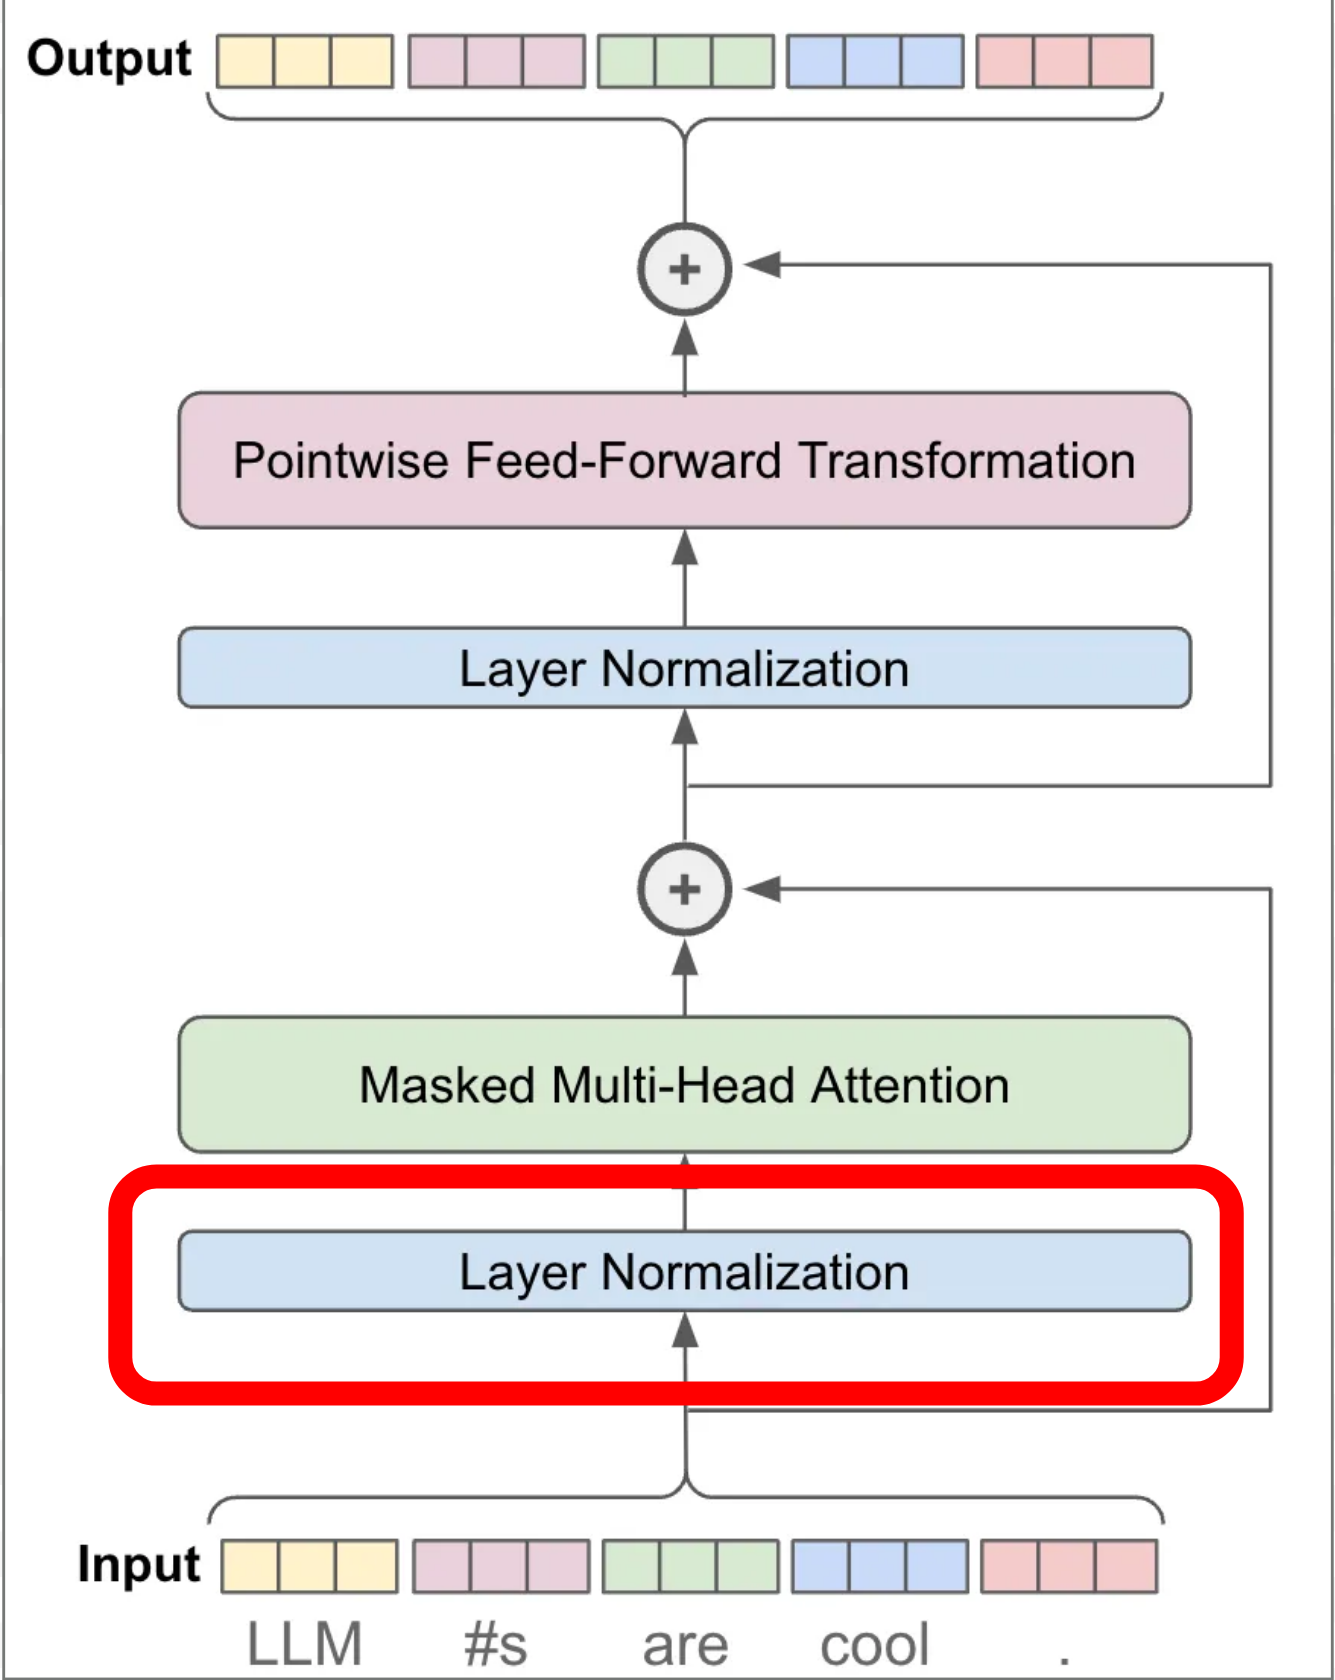

In [ ]:
torch.manual_seed(123)

# create 2 training examples with 5 dimensions (features) each
batch_example = torch.randn(2, 5)

layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [ ]:
mean = out.mean(dim=1, keepdim=True)
var = out.var(dim=1, keepdim=True)
print(f"Mean is {mean}")
print(f"Variance is {var}")

Mean is tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance is tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


In [ ]:
out_norm = (out - mean) / torch.sqrt(var)
print("Normalized layer outputs:\n", out_norm)

mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)


print("Mean:\n", mean)
print("Variance:\n", var)

Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[9.9341e-09],
        [1.9868e-08]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [ ]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [ ]:
ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_example)
print("LayerNorm output:\n", out_ln)

print("Mean:\n", out_ln.mean(dim=1))
print("Variance:\n", out_ln.var(dim=1, unbiased=False, keepdim=True))

LayerNorm output:
 tensor([[ 0.5528,  1.0693, -0.0223,  0.2656, -1.8654],
        [ 0.9087, -1.3767, -0.9564,  1.1304,  0.2940]], grad_fn=<AddBackward0>)
Mean:
 tensor([-2.9802e-08,  0.0000e+00], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


## Multi-Head Attention Layer

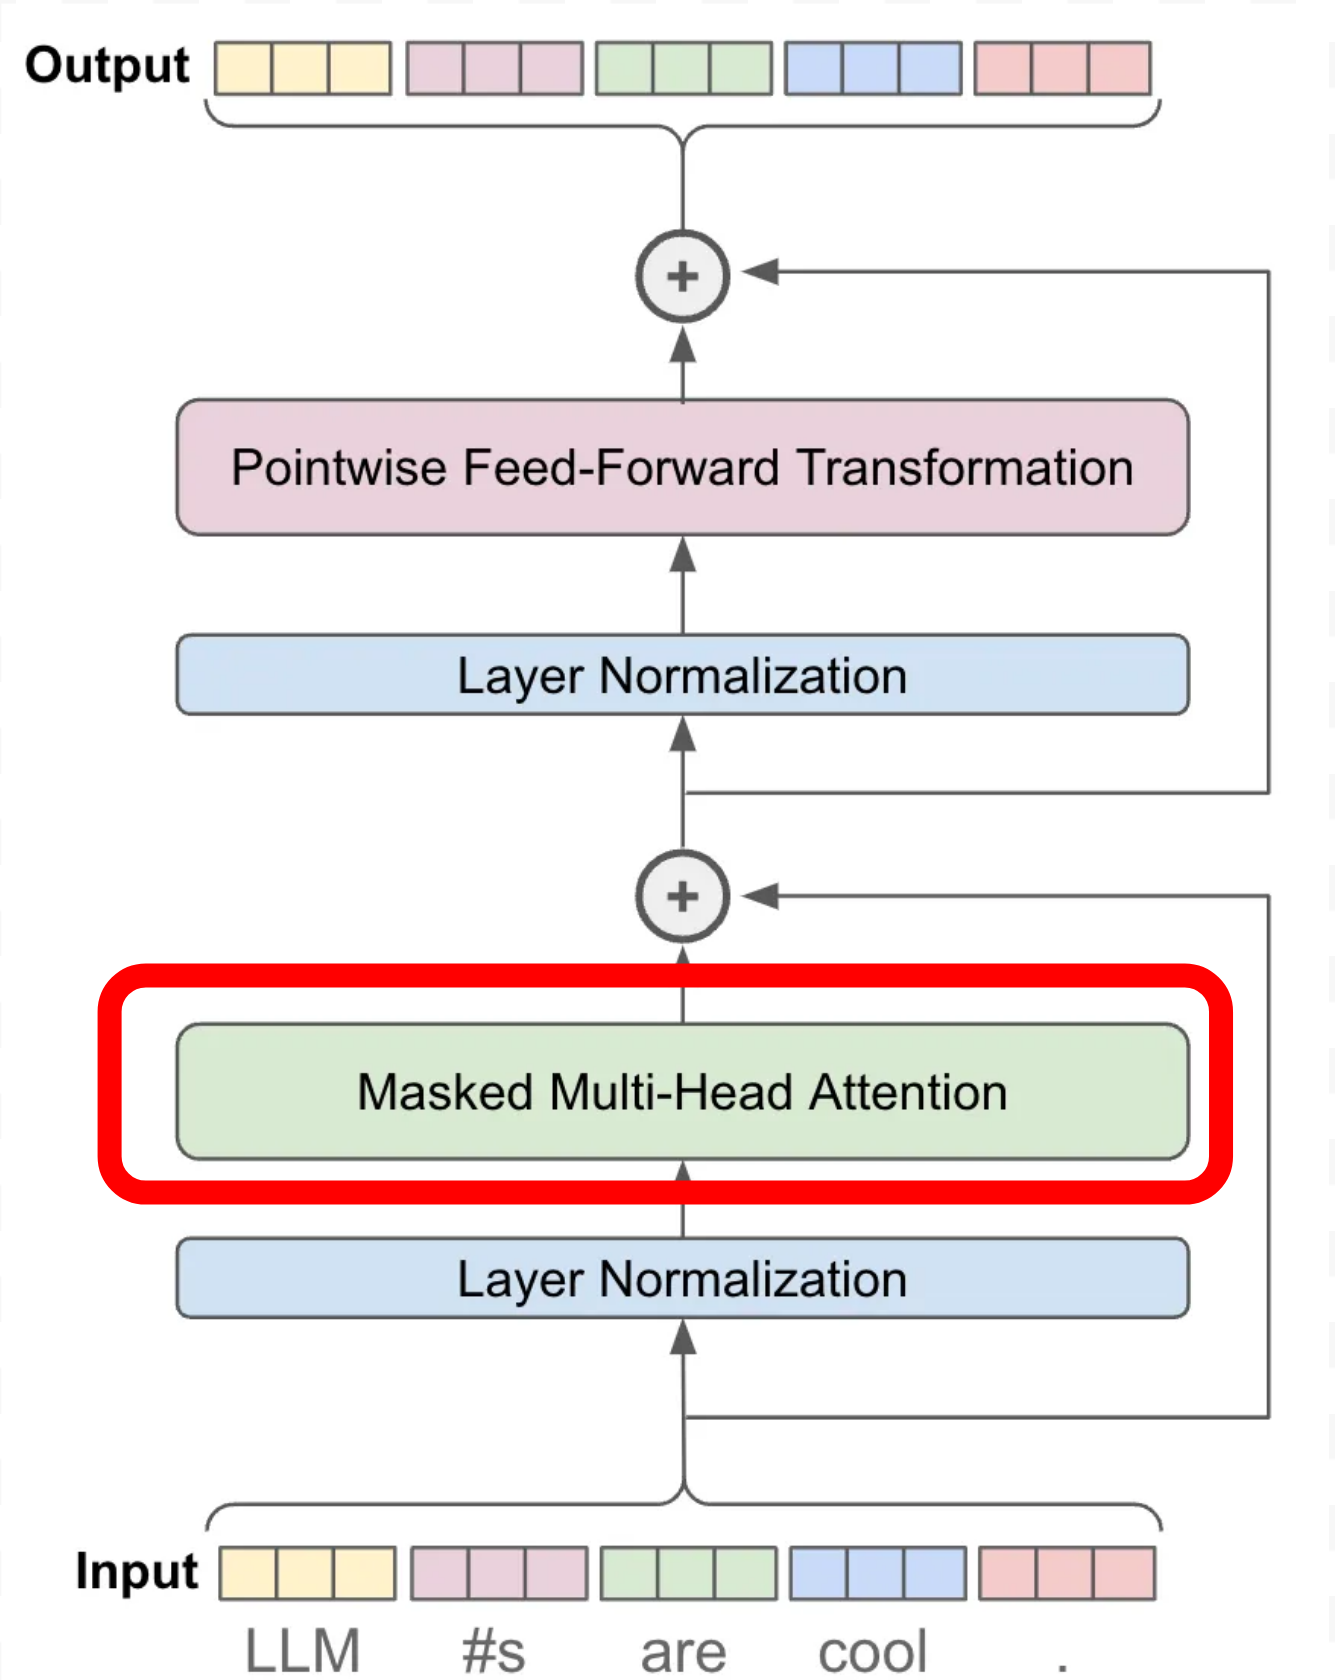

In [ ]:

class MultiHeadAttention(nn.Module):
  def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
    super().__init__()
    self.d_out = d_out
    self.d_in = d_in
    self.num_heads = num_heads
    self.context_length = context_length
    self.dropout = dropout

    assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

    self.head_dim = d_out // num_heads
    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

    self.out_proj = nn.Linear(d_out, d_out)



  def forward(self, X):
    batches, num_tokens, d_in = X.shape # B x L x d_in

    queries = self.W_query(X) # (B x L X d_in) => B x L x d_out)
    keys = self.W_key(X) # (B x L X d_in)  => B x L x d_out)
    values = self.W_value(X) # (B x L X d_in) => B x L x d_out)

    b, num_tokens, d_in = x.shape


    queries = queries.reshape(batches, num_tokens, self.num_heads, self.head_dim) # B x L x num_heads x head_dim
    keys = keys.reshape(batches, num_tokens, self.num_heads, self.head_dim) # B x L x num_heads x head_dim
    values = values.reshape(batches, num_tokens, self.num_heads, self.head_dim) # B x L x num_heads x head_dim

    queries = queries.transpose(1, 2) # B x num_heads x L x head_dim
    keys = keys.transpose(1, 2) # B x num_heads x L x head_dim
    values = values.transpose(1, 2) # B x num_heads x L x head_dim



    attn_scores = queries @ keys.transpose(2, 3) # (B x num_heads x L x head_dim) @ (B x num_heads x head_dim x L) => B x num_heads x L x L

    attn_scores.masked_fill_(self.mask.bool()[:num_tokens, :num_tokens], -torch.inf) # B x num_heads x L x L

    attn_weights = torch.softmax(attn_scores / self.head_dim ** 0.5, dim=-1) # L x L => (1 x 1 x L x L)
    attn_weights = nn.Dropout(self.dropout)(attn_weights) # B x num_heads x L x L

    context_vec = attn_weights @ values # (B x num_heads x L x L) @ (B x num_heads x L x head_dim) => (B x num_heads x L x head_dim)

    context_vec = context_vec.transpose(1, 2) # B x L x num_heads x head_dim
    context_vec = context_vec.reshape(batches, num_tokens, self.d_out) # B x L x d_out

    return self.out_proj(context_vec) # (B x L x d_out) @ (d_out x d_out) => B x L x d_out

## Feedforward Layer

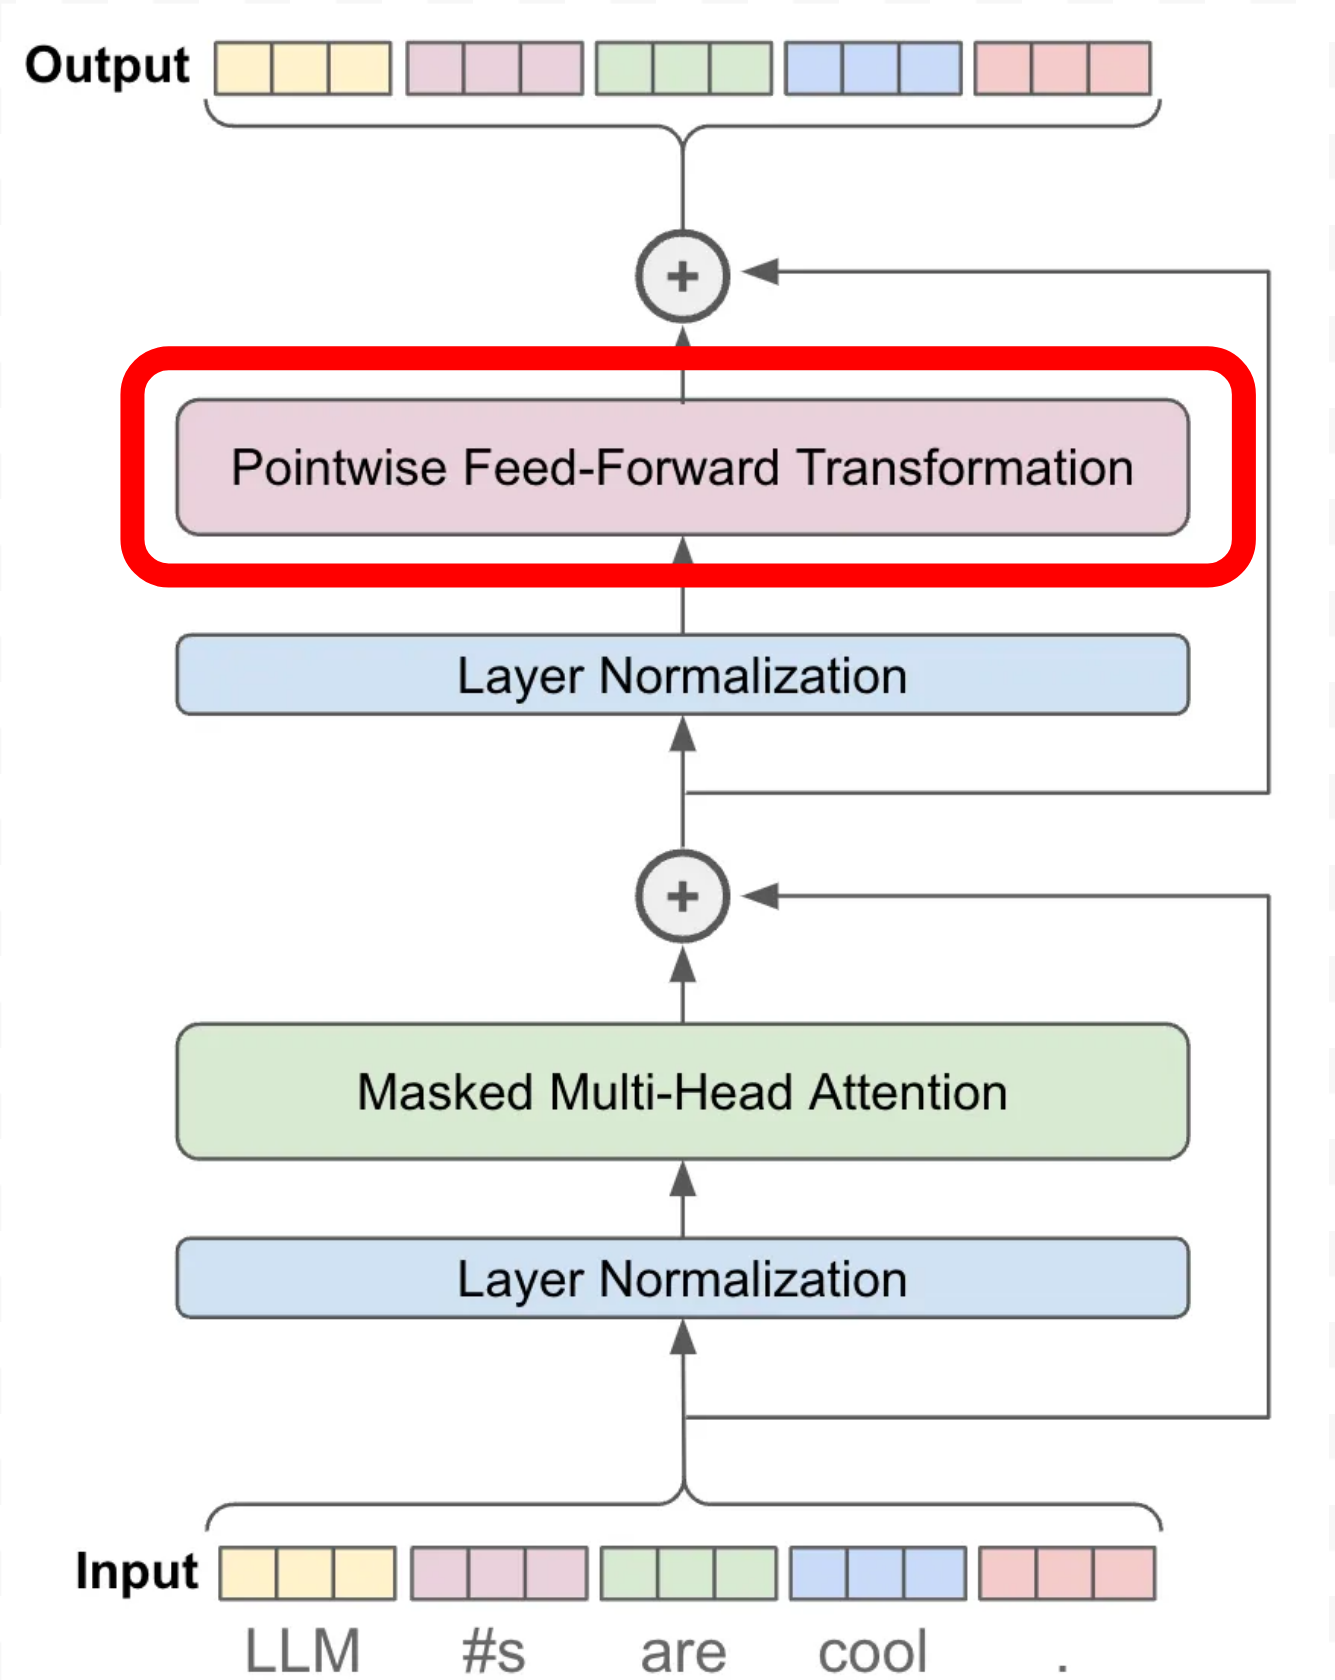

### GELU Activation

$$\text{GELU}(x) = 0.5\cdot x \cdot (1 + \text{tanh}(\sqrt{2/\pi}(x + 0.044715 \cdot x^3)))$$

In [ ]:
import torch.nn as nn

class GELU(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    return 0.5 * x * (1 + torch.tanh(torch.sqrt(torch.tensor(2.0/torch.pi)) * (x + 0.04475*torch.pow(x, 3))))

### FFN

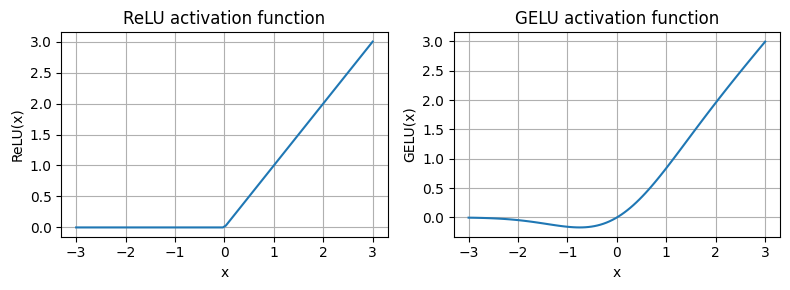

In [ ]:
import matplotlib.pyplot as plt
import torch

gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))

for i, (y, label) in enumerate(zip([y_relu, y_gelu], ["ReLU", "GELU"]), 1):
  plt.subplot(1, 2, i)
  plt.plot(x, y)
  plt.title(f"{label} activation function")
  plt.xlabel("x")
  plt.ylabel(f"{label}(x)")
  plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
class FeedForward(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.layers = nn.Sequential(
          nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
          GELU(),
          nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

  def forward(self, x):
    return self.layers(x)


## Residual Connections

In [ ]:
class ExampleDeepNeuralNetwork(nn.Module):
  def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[i], layer_sizes[i+1]), GELU()) for i in range(len(layer_sizes)-1)
        ])
        self.layers.append(nn.Linear(layer_sizes[-1], 1))

  def forward(self, x):
        for layer in self.layers:
            # Compute the output of the current layer
            layer_output = layer(x)
            # Check if shortcut can be applied
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x


def print_gradients(model, x):
    # Forward pass
    output = model(x)
    target = torch.tensor([[0.]])

    # Calculate loss based on how close the target
    # and output are
    loss = nn.MSELoss()
    loss = loss(output, target)

    # Backward pass to calculate the gradients
    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            # Print the mean absolute gradient of the weights
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [ ]:
# layer_sizes = [3, 4, 5, 3]
layer_sizes = [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 5, 3]

sample_input = torch.tensor([[1., 0., -1.]])

torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=False
)
print_gradients(model_without_shortcut, sample_input)


layers.0.0.weight has gradient mean of 1.913588842938907e-09
layers.1.0.weight has gradient mean of 1.5329271185748894e-09
layers.2.0.weight has gradient mean of 7.849362049228148e-09
layers.3.0.weight has gradient mean of 1.4370560741383542e-08
layers.4.0.weight has gradient mean of 2.653451147693886e-08
layers.5.0.weight has gradient mean of 3.4701358231359336e-07
layers.6.0.weight has gradient mean of 1.5268692550307605e-06
layers.7.0.weight has gradient mean of 8.97088568763138e-07
layers.8.0.weight has gradient mean of 1.1207954230485484e-05
layers.9.0.weight has gradient mean of 2.4795202989480458e-05
layers.10.0.weight has gradient mean of 3.836134783341549e-05
layers.11.0.weight has gradient mean of 0.0001271147484658286
layers.12.0.weight has gradient mean of 0.0010875668376684189
layers.13.weight has gradient mean of 0.10007589310407639


In [ ]:
layer_sizes = [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 5, 3]

sample_input = torch.tensor([[1., 0., -1.]])

torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=True
)
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.0025429180823266506
layers.1.0.weight has gradient mean of 0.00218600663356483
layers.2.0.weight has gradient mean of 0.0030772448517382145
layers.3.0.weight has gradient mean of 0.002185394521802664
layers.4.0.weight has gradient mean of 0.002420594682916999
layers.5.0.weight has gradient mean of 0.004683324135839939
layers.6.0.weight has gradient mean of 0.0021566608920693398
layers.7.0.weight has gradient mean of 0.0006564449868164957
layers.8.0.weight has gradient mean of 0.004534387495368719
layers.9.0.weight has gradient mean of 0.0054245335049927235
layers.10.0.weight has gradient mean of 0.006954381708055735
layers.11.0.weight has gradient mean of 0.002399928169324994
layers.12.0.weight has gradient mean of 0.006077065598219633
layers.13.weight has gradient mean of 0.08127591013908386


## Transformer Block

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x

In [ ]:
torch.manual_seed(123)

x = torch.rand(2, 4, 768) # [batch_size, num_tokens, emb_dim]
trf = TransformerBlock(GPT_CONFIG_124M)
output = trf(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


## Implementing GPT-2 Model

In [ ]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


In [ ]:
GPT_CONFIG_MEDIUM_55M = {
"vocab_size": 50257,
"context_length": 1024,
"emb_dim": 1024,
"n_heads": 16,
"n_layers": 24,
"drop_rate": 0.1,
"qkv_bias": False
}

GPT_CONFIG_LARGE_774M = {
"vocab_size": 50257,
"context_length": 1024,
"emb_dim": 1280,
"n_heads": 20,
"n_layers": 36,
"drop_rate": 0.1,
"qkv_bias": False
}

GPT_CONFIG_XL_1500M = {
"vocab_size": 50257,
"context_length": 1024,
"emb_dim": 1600,
"n_heads": 25,
"n_layers": 48,
"drop_rate": 0.1,
"qkv_bias": False
}


In [ ]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_LARGE_774M)

out = model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)


total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params}")


Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2916e-01, -3.8465e-01,  2.2481e-01,  ...,  5.3690e-01,
           3.6910e-01, -7.6194e-01],
         [ 4.2388e-01,  2.3384e-01, -1.0530e+00,  ..., -8.5493e-02,
          -6.0052e-01, -4.7250e-01],
         [ 2.0737e-01, -6.8014e-01, -4.5403e-02,  ..., -1.2456e+00,
          -8.2942e-01, -1.8727e-02],
         [ 4.6183e-01, -2.8328e-01, -4.0431e-01,  ...,  3.9209e-02,
          -5.2035e-01, -2.3212e-01]],

        [[-6.4384e-01,  1.0075e-01,  2.8045e-01,  ...,  5.6323e-01,
           7.4551e-01, -3.4689e-01],
         [ 5.2567e-01, -3.6398e-04, -1.3889e-01,  ..., -3.7144e-01,
           3.7273e-01,  1.0043e-01],
         [ 3.8735e-01, -7.2590e-01, -1.0607e-01,  ..., -1.1120e+00,
          -4.7452e-01,  2.9558e-01],
         [ 2.3723e-01, -4.2972e-02,  1.7820e-01,  ..., -4.9741e-01,
          -2.3055e-01,  2.4011e-01]]], grad_fn=<UnsafeViewBackward0>)
T